# Competencia Titanic: Predicción de Supervivencia
## Implementación de Metodología CRISP-DM

# Fase 1: Comprensión del negocio
Para abordar este caso desde una perspectiva de análisis de datos y toma de decisiones, establecemos los siguientes criterios:
* **Determinar los objetivos del negocio:** Identificar perfiles de riesgo descubriendo qué características (edad, género, clase) determinaron la probabilidad de supervivencia.
* **Evaluar la situación:** Se cuenta con datos históricos estructurados (`train.csv`) para encontrar patrones y un conjunto de prueba (`test.csv`) para validar la efectividad de las reglas de negocio encontradas.
* **Determinar los objetivos de minería de datos:** Desarrollar un modelo predictivo de clasificación binaria (sobrevive / no sobrevive) que permita generalizar los patrones de supervivencia con alta precisión.

---

# Fase 2: Entendimiento de la data
### Tarea 1: Recopilar datos iniciales
Configuración del entorno de trabajo, importación de librerías base (Pandas, Seaborn) y carga de los conjuntos de datos.


In [110]:
# Librerías para manipulación de datos (equivalente a tu motor de base de datos en memoria)
import pandas as pd
import numpy as np

# Librerías para visualización (te servirán para extraer gráficas para tu exposición)
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica para que las gráficas se vean bien en el notebook
%matplotlib inline
sns.set_style('whitegrid')

In [111]:
# Definir las rutas de los archivos en Kaggle
ruta_train = 'train.csv'
ruta_test = 'test.csv'

# Cargar los datos
train_df = pd.read_csv(ruta_train)
test_df = pd.read_csv(ruta_test)

### Tarea 2: Describir los datos
Inspección de la estructura técnica de la información. Buscamos entender el volumen de datos (filas y columnas) y detectar anomalías tempranas, como el alto porcentaje de valores nulos en la variable `Cabin`.


In [112]:
# Muestra las primeras 5 filas del conjunto de entrenamiento
train_df.head()

# Muestra el tipo de dato de cada columna y cuántos valores nulos hay
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [113]:
# Calcular el porcentaje de valores nulos por columna
nulos_train = train_df.isnull().sum()
porcentaje_nulos = (nulos_train / len(train_df)) * 100

# Crear un DataFrame para visualizarlo mejor
df_nulos = pd.DataFrame({'Valores Faltantes': nulos_train, 'Porcentaje (%)': porcentaje_nulos})
df_nulos[df_nulos['Valores Faltantes'] > 0].sort_values(by='Porcentaje (%)', ascending=False)

,Valores Faltantes,Porcentaje (%)
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


### Tarea 3: Explorar los datos (Análisis Exploratorio - EDA)
Evaluación visual de las dimensiones clave del negocio. Se cruzan variables como Género y Clase del boleto contra la tasa de supervivencia para identificar las correlaciones más fuertes antes de modelar.


C:\Users\saidr\AppData\Local\Temp\ipykernel_60800\30318820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train_df, palette='Set1')


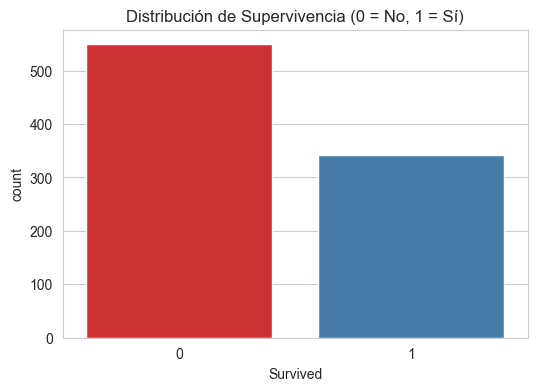

Tasa general de supervivencia: 38.38%


In [114]:
# Graficar la proporción de sobrevivientes
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train_df, palette='Set1')
plt.title('Distribución de Supervivencia (0 = No, 1 = Sí)')
plt.show()

tasa_supervivencia = train_df['Survived'].mean() * 100
print(f"Tasa general de supervivencia: {tasa_supervivencia:.2f}%")

C:\Users\saidr\AppData\Local\Temp\ipykernel_60800\291087383.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=train_df, palette='Set2')


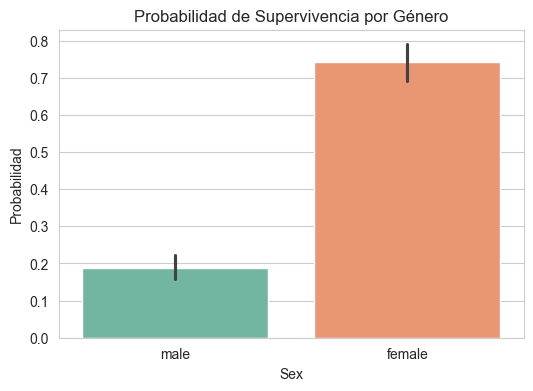

,Sex,Survived
0,female,0.742038
1,male,0.188908


In [115]:
# Supervivencia por género
plt.figure(figsize=(6,4))
sns.barplot(x='Sex', y='Survived', data=train_df, palette='Set2')
plt.title('Probabilidad de Supervivencia por Género')
plt.ylabel('Probabilidad')
plt.show()

# Ver los números exactos
train_df[['Sex', 'Survived']].groupby(['Sex'], as_index=False).mean()

C:\Users\saidr\AppData\Local\Temp\ipykernel_60800\1886216057.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=train_df, palette='Set3')


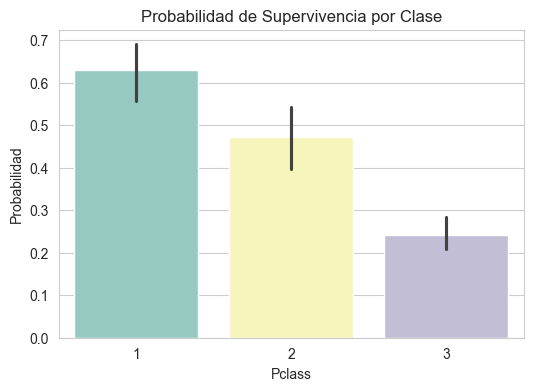

,Pclass,Survived
0,1,0.629630
1,2,0.472826
2,3,0.242363


In [116]:
# Supervivencia por clase de pasajero
plt.figure(figsize=(6,4))
sns.barplot(x='Pclass', y='Survived', data=train_df, palette='Set3')
plt.title('Probabilidad de Supervivencia por Clase')
plt.ylabel('Probabilidad')
plt.show()

# Ver los números exactos
train_df[['Pclass', 'Survived']].groupby(['Pclass'], as_index=False).mean()

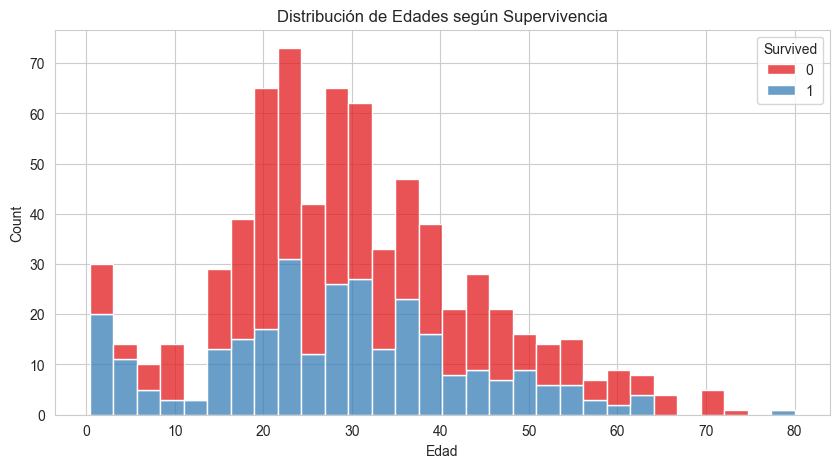

In [117]:
# Histograma de edades separado por supervivencia
plt.figure(figsize=(10,5))
sns.histplot(data=train_df, x='Age', hue='Survived', multiple='stack', bins=30, palette='Set1')
plt.title('Distribución de Edades según Supervivencia')
plt.xlabel('Edad')
plt.show()

---

# Fase 3: Preparación de la data
### Tarea 1: Limpiar los datos
Tratamiento de valores atípicos y nulos. Se descarta la variable `Cabin` por exceso de ruido y se rescata `Age` imputando la mediana para mantener la integridad estadística de la distribución.


In [118]:
# 1. Limpieza de datos (Data Cleaning)
# Trabajaremos con una copia para no alterar los datos originales explorados
train_clean = train_df.copy()
test_clean = test_df.copy()

# A) Imputación de la Edad: Usaremos la mediana para no sesgar por valores atípicos
mediana_edad = train_clean['Age'].median()
train_clean['Age'] = train_clean['Age'].fillna(mediana_edad)
test_clean['Age'] = test_clean['Age'].fillna(mediana_edad)

# B) Imputación de Embarked (Puerto): Rellenamos con el valor más común (la moda)
puerto_frecuente = train_clean['Embarked'].mode()[0]
train_clean['Embarked'] = train_clean['Embarked'].fillna(puerto_frecuente)

# C) Test tiene un nulo en 'Fare' (Tarifa), lo rellenamos con la mediana
test_clean['Fare'] = test_clean['Fare'].fillna(test_clean['Fare'].median())

# D) Descartar la columna Cabin por tener casi 80% de nulos
train_clean = train_clean.drop(columns=['Cabin'])
test_clean = test_clean.drop(columns=['Cabin'])

print("Limpieza completada. Nulos restantes en Train:", train_clean.isnull().sum().sum())

Limpieza completada. Nulos restantes en Train: 0


### Tarea 2: Construir nuevos datos (Feature Engineering)
Creación de nuevas dimensiones analíticas. Se consolidan las relaciones familiares en la variable `FamilySize` y se deriva el indicador booleano `IsAlone` para perfilar mejor el comportamiento humano durante el evento.


In [119]:
# 2. Construcción de datos (Feature Engineering)
datasets = [train_clean, test_clean]

for data in datasets:
    # Crear variable 'Tamaño de Familia' (Hermanos/Esposos + Padres/Hijos + 1 que es el pasajero)
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    
    # Crear variable binaria 'Viaja Solo' para perfilar mejor el riesgo
    data['IsAlone'] = 0
    data.loc[data['FamilySize'] == 1, 'IsAlone'] = 1

# Ver cómo luce esta nueva variable cruzada con la supervivencia
train_clean[['IsAlone', 'Survived']].groupby(['IsAlone'], as_index=False).mean()

,IsAlone,Survived
0,0,0.505650
1,1,0.303538


### Tarea 3: Formatear y transformar datos
Conversión de todo el texto categórico a formato numérico binario, un requisito técnico estricto para que los algoritmos de clasificación matemática puedan procesar la información.


In [120]:
# 3. Formatear datos (Transformación a numéricos)
for data in datasets:
    # Mapeo de Género
    data['Sex'] = data['Sex'].map({'male': 0, 'female': 1}).astype(int)
    
    # Mapeo de Puerto de Embarque (S=0, C=1, Q=2)
    data['Embarked'] = data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

# Finalmente, eliminamos columnas de texto que no aportan al modelo estadístico base
columnas_a_eliminar = ['Name', 'Ticket', 'PassengerId']

# Guardamos el PassengerId de test porque Kaggle lo pide para el archivo final
passenger_id_test = test_clean['PassengerId'] 

train_clean = train_clean.drop(columns=columnas_a_eliminar)
test_clean = test_clean.drop(columns=columnas_a_eliminar)

# Mostrar cómo quedó nuestra tabla final, lista para modelar
train_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,0,2,0
1,1,1,1,38.0,1,0,71.2833,1,2,0
2,1,3,1,26.0,0,0,7.9250,0,1,1
3,1,1,1,35.0,1,0,53.1000,0,2,0
4,0,3,0,35.0,0,0,8.0500,0,1,1


---

# Fase 4: Modelación
### Tarea 1: Generar el diseño de prueba
Separación del conjunto histórico limpio en 80% para aprendizaje y 20% para validación interna, garantizando una evaluación imparcial del algoritmo.


In [121]:
# Importar la herramienta para dividir los datos
from sklearn.model_selection import train_test_split

# Separar las características (X) de la variable objetivo que queremos predecir (y)
X = train_clean.drop(columns=['Survived'])
y = train_clean['Survived']

# Dividir en 80% entrenamiento y 20% validación local
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos para entrenar el algoritmo: {X_train.shape[0]} registros.")
print(f"Datos para validar el algoritmo: {X_val.shape[0]} registros.")

Datos para entrenar el algoritmo: 712 registros.
Datos para validar el algoritmo: 179 registros.


### Tarea 2: Seleccionar la técnica de modelado
Se implementa un modelo **Random Forest (Bosque Aleatorio)**. Esta técnica se elige por su robustez ante datos no lineales y su alta interpretabilidad de negocio al permitir extraer la importancia exacta de cada variable.


In [122]:
# Importar el algoritmo Random Forest
from sklearn.ensemble import RandomForestClassifier

# Configurar los parámetros del modelo (hiperparámetros base)
# n_estimators = número de árboles de decisión
# max_depth = profundidad máxima para evitar que el modelo memorice los datos (overfitting)
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

### Tarea 3: Construir el modelo
Entrenamiento del algoritmo y extracción de las reglas de decisión generadas.


C:\Users\saidr\AppData\Local\Temp\ipykernel_60800\1465647663.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis')


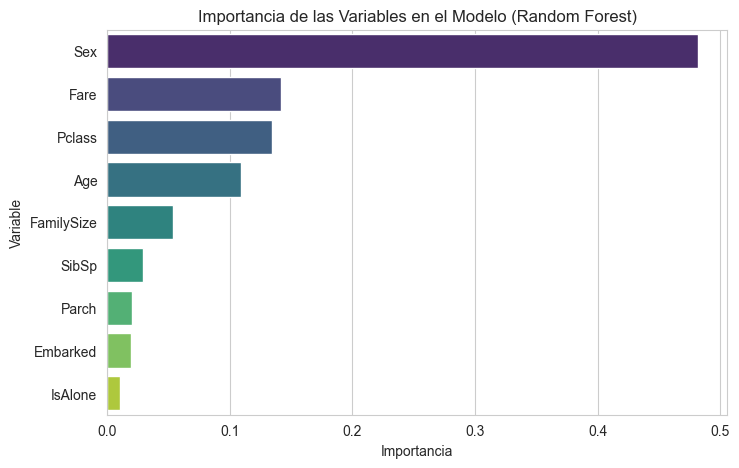

In [123]:
# Entrenar (ajustar) el modelo con los datos de entrenamiento
modelo_rf.fit(X_train, y_train)

# Extraer la importancia de las variables (Feature Importance)
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': modelo_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Graficar la importancia de las variables para la exposición
plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia', y='Variable', data=importancias, palette='viridis')
plt.title('Importancia de las Variables en el Modelo (Random Forest)')
plt.show()

---

# Fase 5: Evaluación
### Tarea 1: Evaluar los resultados
Medición del rendimiento del modelo utilizando los datos de validación. Se analiza la precisión general (Accuracy) y la Matriz de Confusión para contabilizar los falsos positivos y falsos negativos.


Precisión del modelo (Accuracy): 81.56%

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



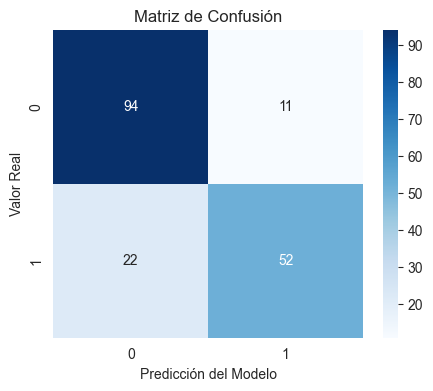

In [124]:
# Importar métricas de evaluación
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Hacer predicciones con los datos de validación
predicciones_val = modelo_rf.predict(X_val)

# Calcular la precisión general
precision = accuracy_score(y_val, predicciones_val)
print(f"Precisión del modelo (Accuracy): {precision * 100:.2f}%\n")

# Reporte detallado de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_val, predicciones_val))

# Matriz de confusión para ver visualmente los aciertos y errores
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_val, predicciones_val), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

### Tarea 2: Revisar el proceso y generar el entregable final
Tras confirmar la viabilidad del modelo sin sobreajuste, se aplican las reglas al conjunto de prueba oficial para exportar el archivo de predicciones de salida estandarizado.


In [125]:
# Generar predicciones finales sobre el conjunto de prueba (test.csv limpio)
predicciones_finales = modelo_rf.predict(test_clean)

# Crear el DataFrame con la estructura requerida por Kaggle
submission = pd.DataFrame({
    "PassengerId": passenger_id_test,
    "Survived": predicciones_finales
})

# Guardar el DataFrame como un archivo CSV sin el índice de Pandas
submission.to_csv('submission.csv', index=False)

print("¡Archivo submission.csv generado con éxito!")
# Visualizar las primeras filas del entregable
submission.head()

¡Archivo submission.csv generado con éxito!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
